# EMA 21/13/8 Scalping Strategy (H1 + M5)

This notebook implements your requested idea in **separate blocks**:

1. Load data from local cache (`./data/<symbol>/<timeframe>`)
2. Build EMA indicators (`21`, `13`, `8`)
3. Use `H1` as trend confirmation
4. On `M5`, place pending stop order `3 pips` beyond last `5` candles high/low
5. Use `TP:SL = 1:1`
6. Expire pending orders after `60 minutes`
7. Backtest and show pilot result on chart

Reference video you shared: https://www.youtube.com/watch?v=zhEukjCzXwM

In [354]:
# SECTION 1 - Imports and parameters
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# === User parameters ===
SYMBOL = "USDJPY"   
# change this (e.g., BTCUSD, ETHUSD, XRPUSD, BCHUSD, BNBUSD, 
# EURUSD, NZDJPY, CADJPY, XAGUSD, XAUUSD, USDJPY, USDCAD, USDCHF,
# EURCZK, EURHUF, EURTRY, EURZAR, GBPTRY, GBPZAR, USDCZK,
# USDHUF, USDMXN, USDTRY, USDZAR, AUDUSD ,GBPUSD, NZDUSD,
# AUDCAD, AUDCHF, AUDJPY, AUDNZD, CADCHF)
TF_ENTRY = "M5"
TF_TREND = "H1"

EMA_FAST = 8
EMA_MID = 13
EMA_SLOW = 21

LOOKBACK_BARS = 5
PENDING_OFFSET_PIPS = 3.0
PENDING_EXPIRY_MIN = 60
RR = 1.0  # TP:SL = 1:1

# Pip size helper (simple default)
# For JPY pairs often 0.01, most FX 0.0001, metals/indices vary by broker.
PIP_SIZE = 0.01 if "JPY" in SYMBOL else 0.0001
if SYMBOL.startswith("XAU"):
    PIP_SIZE = 0.1

START_BALANCE = 10000.0
RISK_PER_TRADE = 0.01

# Limit backtest/chart M5 history to the last BARS rows (trim applied in Section 4 after H1→M5 mapping).
# EMA + merge still see full loaded history first so rows inside the window are warmed up.
BARS = None  # e.g. 2000

print(f"Symbol={SYMBOL}, Trend={TF_TREND}, Entry={TF_ENTRY}, PipSize={PIP_SIZE}, BARS={BARS}")


Symbol=USDJPY, Trend=H1, Entry=M5, PipSize=0.01, BARS=None


In [355]:
# SECTION 2 - Load data from cache: ./data/<symbol>/<timeframe>
def _standardize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",
        "o": "open", "h": "high", "l": "low", "c": "close", "v": "volume",
        "tick_volume": "volume",
    }
    df = df.rename(columns=rename_map)

    if not isinstance(df.index, pd.DatetimeIndex):
        dt_cols = [c for c in ["time", "datetime", "date", "timestamp"] if c in df.columns]
        if dt_cols:
            dt_col = dt_cols[0]
            df[dt_col] = pd.to_datetime(df[dt_col], utc=False, errors="coerce")
            df = df.set_index(dt_col)
        else:
            first = df.columns[0]
            maybe_dt = pd.to_datetime(df[first], utc=False, errors="coerce")
            if maybe_dt.notna().mean() > 0.8:
                df[first] = maybe_dt
                df = df.set_index(first)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Could not infer datetime index from cache file.")

    need = ["open", "high", "low", "close"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise ValueError(f"Missing OHLC columns: {miss}")

    if "volume" not in df.columns:
        df["volume"] = 1.0

    out = df[["open", "high", "low", "close", "volume"]].copy()
    out = out.sort_index().dropna()
    return out


def load_cached_timeframe(symbol: str, timeframe: str, base_dir: str = "./data") -> pd.DataFrame:
    folder = Path(base_dir) / symbol / timeframe
    if not folder.exists():
        # fallback to lowercase timeframe folders if needed
        alt = Path(base_dir) / symbol / timeframe.lower()
        if alt.exists():
            folder = alt
        else:
            raise FileNotFoundError(f"Cache folder not found: {folder}")

    files = sorted(
        [*folder.glob("*.parquet"), *folder.glob("*.csv")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not files:
        raise FileNotFoundError(f"No cache file found in {folder}")

    path = files[0]
    df = pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)
    df = _standardize_ohlcv(df)
    print(f"Loaded {len(df):,} rows from {path}")
    return df

m5 = load_cached_timeframe(SYMBOL, TF_ENTRY)
h1 = load_cached_timeframe(SYMBOL, TF_TREND)

display(m5.head(3))
display(h1.head(3))

Loaded 100,000 rows from data\USDJPY\M5\ohlcv.csv
Loaded 8,000 rows from data\USDJPY\H1\ohlcv.csv


,open,high,low,close,volume
time,,,,,
2025-01-06 10:20:00+00:00,157.689,157.737,157.682,157.732,371
2025-01-06 10:25:00+00:00,157.734,157.760,157.698,157.700,359
2025-01-06 10:30:00+00:00,157.698,157.713,157.664,157.702,350


,open,high,low,close,volume
time,,,,,
2025-01-24 14:00:00+00:00,156.093,156.470,156.060,156.453,4963
2025-01-24 15:00:00+00:00,156.453,156.572,156.237,156.318,5590
2025-01-24 16:00:00+00:00,156.320,156.479,156.070,156.306,7299


In [356]:
# SECTION 3 - Build EMA 21/13/8 on both timeframes
for df in (m5, h1):
    df[f"ema_{EMA_FAST}"] = df["close"].ewm(span=EMA_FAST, adjust=False).mean()
    df[f"ema_{EMA_MID}"] = df["close"].ewm(span=EMA_MID, adjust=False).mean()
    df[f"ema_{EMA_SLOW}"] = df["close"].ewm(span=EMA_SLOW, adjust=False).mean()

print("EMA columns added.")
display(h1[["close", f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))

EMA columns added.


,close,ema_8,ema_13,ema_21
time,,,,
2026-05-08 19:00:00+00:00,156.688,156.665286,156.685728,156.686301
2026-05-08 20:00:00+00:00,156.678,156.668111,156.684624,156.685546
2026-05-08 21:00:00+00:00,156.682,156.671198,156.684249,156.685224
2026-05-08 22:00:00+00:00,156.717,156.681376,156.688928,156.688113
2026-05-08 23:00:00+00:00,156.683,156.681737,156.688081,156.687648


In [357]:
# SECTION 4 - H1 trend direction confirmation
# Bull trend: EMA8 > EMA13 > EMA21 and close > EMA21
# Bear trend: EMA8 < EMA13 < EMA21 and close < EMA21

h1_sig = h1.copy()

h1_sig["trend"] = "flat"
h1_sig.loc[
    (h1_sig[f"ema_{EMA_FAST}"] > h1_sig[f"ema_{EMA_MID}"]) &
    (h1_sig[f"ema_{EMA_MID}"] > h1_sig[f"ema_{EMA_SLOW}"]) &
    (h1_sig["close"] > h1_sig[f"ema_{EMA_SLOW}"]),
    "trend"
] = "bull"

h1_sig.loc[
    (h1_sig[f"ema_{EMA_FAST}"] < h1_sig[f"ema_{EMA_MID}"]) &
    (h1_sig[f"ema_{EMA_MID}"] < h1_sig[f"ema_{EMA_SLOW}"]) &
    (h1_sig["close"] < h1_sig[f"ema_{EMA_SLOW}"]),
    "trend"
] = "bear"

# Map H1 trend onto M5 timeline
m5_ctx = pd.merge_asof(
    m5.sort_index(),
    h1_sig[["trend", f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].sort_index(),
    left_index=True,
    right_index=True,
    direction="backward",
    suffixes=("", "_h1")
)

print(m5_ctx["trend"].value_counts(dropna=False))

if BARS is not None:
    _bars_n = int(BARS)
    if _bars_n > 0:
        _before = len(m5_ctx)
        m5_ctx = m5_ctx.iloc[-_bars_n:].copy()
        m5 = m5.loc[m5_ctx.index].copy()
        if _before > _bars_n:
            print(f"BARS={_bars_n}: trimmed M5 window {_before} -> {len(m5_ctx)} rows")
        if len(m5_ctx) < LOOKBACK_BARS + 2:
            print(
                f"Warning: only {len(m5_ctx)} M5 bars after trim; "
                f"strategy loop starts after LOOKBACK_BARS={LOOKBACK_BARS}."
            )


display(m5_ctx[["close", "trend"]].tail(8))

trend
bull    41794
bear    34828
flat    19304
NaN      4074
Name: count, dtype: int64


,close,trend
time,,
2026-05-08 23:15:00+00:00,156.686,flat
2026-05-08 23:20:00+00:00,156.682,flat
2026-05-08 23:25:00+00:00,156.682,flat
2026-05-08 23:30:00+00:00,156.681,flat
2026-05-08 23:35:00+00:00,156.652,flat
2026-05-08 23:40:00+00:00,156.666,flat
2026-05-08 23:45:00+00:00,156.670,flat
2026-05-08 23:50:00+00:00,156.683,flat


In [358]:
# SECTION 5 - Strategy engine (pending stop orders + expiry + TP/SL)
def run_backtest(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    data = data.copy().sort_index()

    expiry_bars = max(1, int(PENDING_EXPIRY_MIN / 5))  # M5 -> 12 bars for 60m

    trades = []
    balance = START_BALANCE
    equity_curve = []

    pending = None   # dict or None
    position = None  # dict or None

    for i in range(LOOKBACK_BARS, len(data)):
        idx = data.index[i]
        row = data.iloc[i]

        # mark-to-market equity (simple close-based)
        floating = 0.0
        if position is not None:
            if position["side"] == "buy":
                floating = (row["close"] - position["entry"]) * position["qty"]
            else:
                floating = (position["entry"] - row["close"]) * position["qty"]
        equity_curve.append((idx, balance + floating))

        # 1) manage open position first
        if position is not None:
            hit_sl = False
            hit_tp = False

            if position["side"] == "buy":
                hit_sl = row["low"] <= position["sl"]
                hit_tp = row["high"] >= position["tp"]
            else:
                hit_sl = row["high"] >= position["sl"]
                hit_tp = row["low"] <= position["tp"]

            if hit_sl or hit_tp:
                # conservative fill priority: SL first if both touched in same candle
                exit_price = position["sl"] if hit_sl else position["tp"]
                pnl = (exit_price - position["entry"]) * position["qty"]
                if position["side"] == "sell":
                    pnl = -pnl

                balance += pnl
                trades.append({
                    "entry_time": position["entry_time"],
                    "exit_time": idx,
                    "side": position["side"],
                    "entry": position["entry"],
                    "sl": position["sl"],
                    "tp": position["tp"],
                    "exit": exit_price,
                    "qty": position["qty"],
                    "pnl": pnl,
                    "balance_after": balance,
                    "result": "win" if pnl > 0 else "loss",
                })
                position = None
            continue

        # 2) manage pending order expiry / trigger
        if pending is not None:
            age = i - pending["created_i"]
            if age > expiry_bars:
                pending = None
            else:
                if pending["side"] == "buy":
                    if row["high"] >= pending["entry"]:
                        position = {
                            "side": "buy",
                            "entry": pending["entry"],
                            "sl": pending["sl"],
                            "tp": pending["tp"],
                            "qty": pending["qty"],
                            "entry_time": idx,
                        }
                        pending = None
                else:
                    if row["low"] <= pending["entry"]:
                        position = {
                            "side": "sell",
                            "entry": pending["entry"],
                            "sl": pending["sl"],
                            "tp": pending["tp"],
                            "qty": pending["qty"],
                            "entry_time": idx,
                        }
                        pending = None

        # 3) if free, place new pending order based on trend and last 5 candles
        if pending is None and position is None:
            window = data.iloc[i-LOOKBACK_BARS:i]
            hh = window["high"].max()
            ll = window["low"].min()

            trend = row.get("trend", "flat")
            offset = PENDING_OFFSET_PIPS * PIP_SIZE

            if trend == "bull":
                entry = hh + offset
                sl = ll - offset
                risk_per_unit = max(entry - sl, 1e-12)
                tp = entry + RR * risk_per_unit
                risk_cash = balance * RISK_PER_TRADE
                qty = risk_cash / risk_per_unit

                pending = {
                    "side": "buy",
                    "entry": float(entry),
                    "sl": float(sl),
                    "tp": float(tp),
                    "qty": float(qty),
                    "created_i": i,
                }

            elif trend == "bear":
                entry = ll - offset
                sl = hh + offset
                risk_per_unit = max(sl - entry, 1e-12)
                tp = entry - RR * risk_per_unit
                risk_cash = balance * RISK_PER_TRADE
                qty = risk_cash / risk_per_unit

                pending = {
                    "side": "sell",
                    "entry": float(entry),
                    "sl": float(sl),
                    "tp": float(tp),
                    "qty": float(qty),
                    "created_i": i,
                }

    trades_df = pd.DataFrame(trades)
    eq = pd.Series({t: v for t, v in equity_curve}).sort_index()
    return trades_df, eq

trades_df, equity_curve = run_backtest(m5_ctx)
print(f"Total trades: {len(trades_df)}")
display(trades_df.head(10))

Total trades: 1591


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result
0,2025-01-24 16:10:00+00:00,2025-01-24 16:20:00+00:00,sell,156.207,156.433,155.981,156.433,442.477876,-100.000000,9900.000000,loss
1,2025-01-24 16:45:00+00:00,2025-01-24 17:20:00+00:00,sell,156.164,156.464,155.864,155.864,330.000000,99.000000,9999.000000,win
2,2025-01-24 17:30:00+00:00,2025-01-27 10:35:00+00:00,sell,155.824,156.417,155.231,155.231,168.617201,99.990000,10098.990000,win
3,2025-01-27 10:45:00+00:00,2025-01-27 11:10:00+00:00,sell,155.159,155.516,154.802,154.802,282.884874,100.989900,10199.979900,win
4,2025-01-27 11:55:00+00:00,2025-01-27 12:40:00+00:00,sell,154.563,155.216,153.910,153.910,156.201836,101.999799,10301.979699,win
5,2025-01-27 12:50:00+00:00,2025-01-27 14:10:00+00:00,sell,153.879,154.197,153.561,154.197,323.961626,-103.019797,10198.959902,loss
6,2025-01-27 18:25:00+00:00,2025-01-27 20:30:00+00:00,sell,154.195,154.502,153.888,154.502,332.213678,-101.989599,10096.970303,loss
7,2025-01-27 21:45:00+00:00,2025-01-28 01:15:00+00:00,sell,154.530,154.745,154.315,154.745,469.626526,-100.969703,9996.000600,loss
8,2025-01-28 05:20:00+00:00,2025-01-28 09:50:00+00:00,buy,155.694,155.423,155.965,155.965,368.856111,99.960006,10095.960606,win
9,2025-01-28 11:15:00+00:00,2025-01-28 11:30:00+00:00,buy,155.795,155.536,156.054,155.536,389.805429,-100.959606,9995.001000,loss


In [359]:
# SECTION 6 - Backtest metrics (pilot result numbers)
def max_drawdown_pct(equity: pd.Series | None) -> float:
    """Peak-to-trough drawdown as % of running peak equity."""
    if equity is None or len(equity) < 2:
        return 0.0
    eq = pd.Series(equity).astype(float).dropna()
    if eq.empty:
        return 0.0
    peak = eq.cummax()
    dd = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize_results(
    trades: pd.DataFrame,
    start_balance: float,
    equity: pd.Series | None = None,
) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{
            "trades": 0,
            "win_rate_%": 0.0,
            "net_pnl": 0.0,
            "avg_pnl": 0.0,
            "profit_factor": 0.0,
            "max_drawdown_%": round(max_drawdown_pct(equity), 2),
            "start_balance": start_balance,
            "end_balance": start_balance,
            "return_%": 0.0,
        }])

    wins = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]

    gross_profit = wins.sum() if not wins.empty else 0.0
    gross_loss = abs(losses.sum()) if not losses.empty else 0.0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    end_balance = trades["balance_after"].iloc[-1]
    result = {
        "trades": int(len(trades)),
        "win_rate_%": round((trades["pnl"] > 0).mean() * 100, 2),
        "net_pnl": round(trades["pnl"].sum(), 2),
        "avg_pnl": round(trades["pnl"].mean(), 2),
        "profit_factor": round(float(profit_factor), 3) if pd.notna(profit_factor) else np.nan,
        "max_drawdown_%": round(max_drawdown_pct(equity), 2),
        "start_balance": round(start_balance, 2),
        "end_balance": round(float(end_balance), 2),
        "return_%": round(((end_balance / start_balance) - 1) * 100, 2),
    }
    return pd.DataFrame([result])


# Trade columns: price difference (exit - entry) and running sum of pnl (last column)
if not trades_df.empty:
    trades_df = trades_df.copy()
    trades_df["exit_minus_entry"] = trades_df["exit"] - trades_df["entry"]
    trades_df["cumulative_pnl"] = trades_df["pnl"].cumsum()
    _base_cols = [c for c in trades_df.columns if c not in ("exit_minus_entry", "cumulative_pnl")]
    trades_df = trades_df[_base_cols + ["exit_minus_entry", "cumulative_pnl"]]

summary = summarize_results(trades_df, START_BALANCE, equity_curve)
display(summary)

if not trades_df.empty:
    display(trades_df.tail(10))

,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,1591,55.88,49924.98,31.38,1.229,13.22,10000.0,59924.98,499.25


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result,exit_minus_entry,cumulative_pnl
1581,2026-05-06 13:40:00+00:00,2026-05-06 13:55:00+00:00,sell,155.830,156.033,155.627,155.627,3073.982415,624.018430,63025.861463,win,-0.203,53025.861463
1582,2026-05-06 16:35:00+00:00,2026-05-06 18:05:00+00:00,sell,156.089,156.333,155.845,156.333,2583.027109,-630.258615,62395.602848,loss,0.244,52395.602848
1583,2026-05-06 23:10:00+00:00,2026-05-07 02:50:00+00:00,sell,156.308,156.456,156.160,156.456,4215.919111,-623.956028,61771.646820,loss,0.148,51771.646820
1584,2026-05-07 03:10:00+00:00,2026-05-07 04:10:00+00:00,sell,156.367,156.544,156.190,156.190,3489.923549,617.716468,62389.363288,win,-0.177,52389.363288
1585,2026-05-07 04:30:00+00:00,2026-05-07 14:50:00+00:00,sell,156.057,156.431,155.683,156.431,1668.164794,-623.893633,61765.469655,loss,0.374,51765.469655
1586,2026-05-07 15:25:00+00:00,2026-05-07 18:50:00+00:00,sell,156.315,156.492,156.138,156.492,3489.574557,-617.654697,61147.814959,loss,0.177,51147.814959
1587,2026-05-07 20:15:00+00:00,2026-05-07 20:35:00+00:00,buy,156.664,156.517,156.811,156.811,4159.715303,611.478150,61759.293108,win,0.147,51759.293108
1588,2026-05-07 23:30:00+00:00,2026-05-08 11:40:00+00:00,buy,156.866,156.660,157.072,156.660,2998.023937,-617.592931,61141.700177,loss,-0.206,51141.700177
1589,2026-05-08 13:45:00+00:00,2026-05-08 15:30:00+00:00,buy,156.729,156.598,156.860,156.598,4667.305357,-611.417002,60530.283175,loss,-0.131,50530.283175
1590,2026-05-08 20:25:00+00:00,2026-05-08 21:55:00+00:00,sell,156.606,156.723,156.489,156.723,5173.528477,-605.302832,59924.980344,loss,0.117,49924.980344


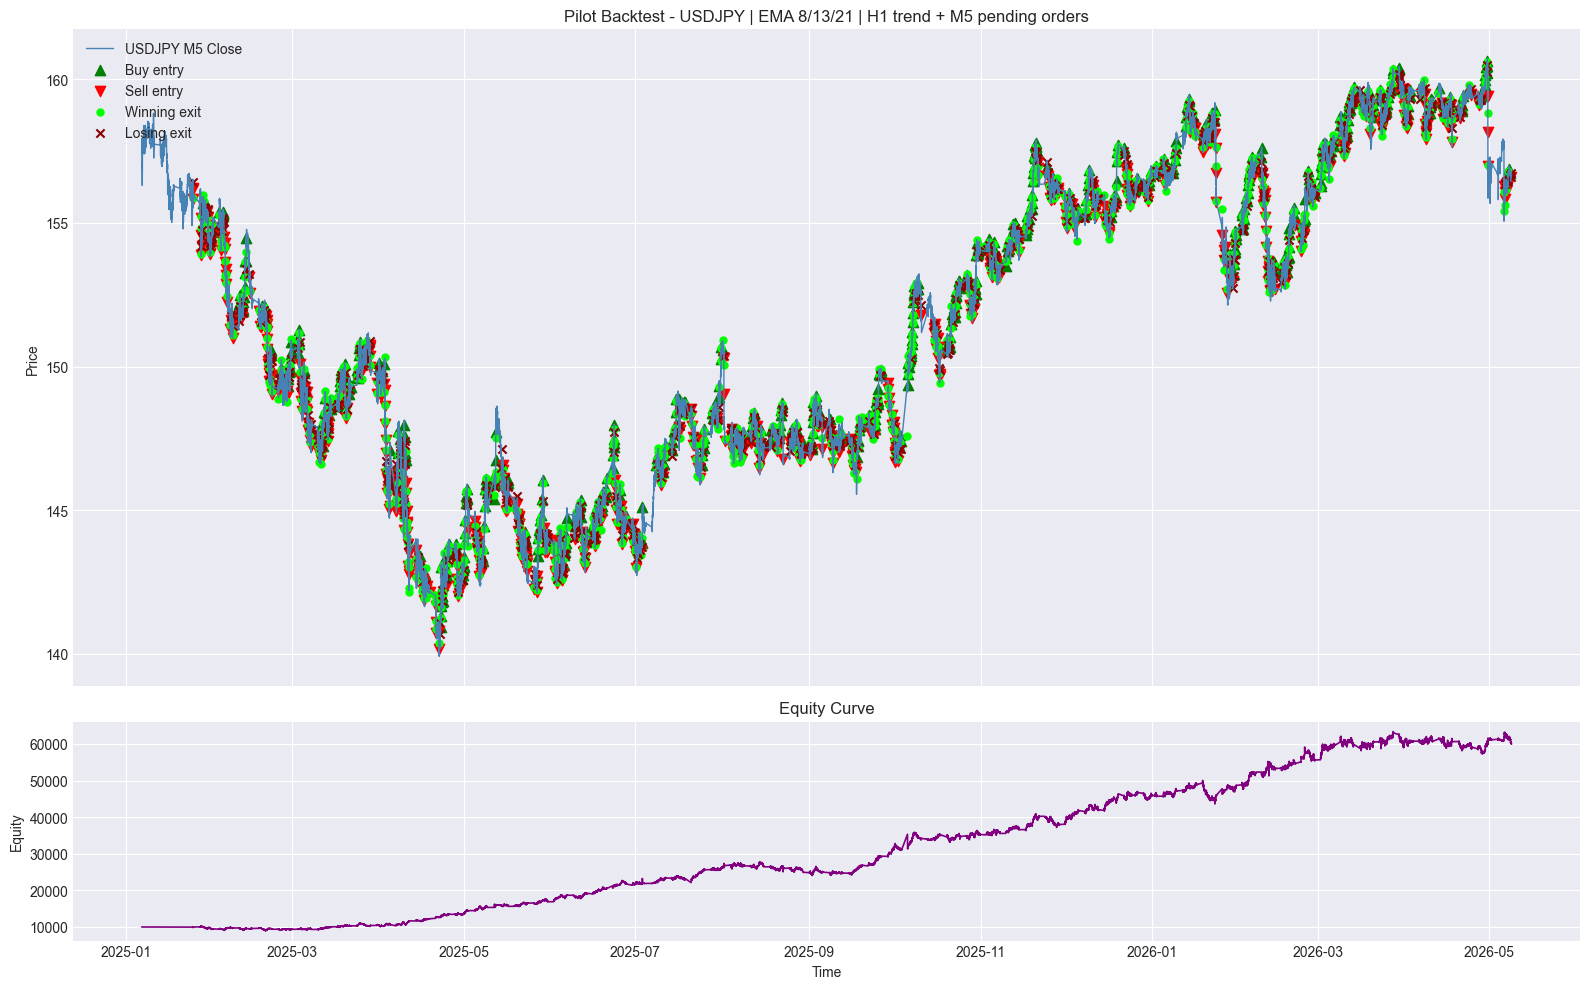

In [360]:
# SECTION 7 - Pilot result chart (price + entries/exits + equity)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax_price, ax_eq = axes

# price line (you can replace with candlestick later)
ax_price.plot(m5_ctx.index, m5_ctx["close"], label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=1.0)

if not trades_df.empty:
    buys = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]

    ax_price.scatter(buys["entry_time"], buys["entry"], marker="^", color="green", s=55, label="Buy entry")
    ax_price.scatter(sells["entry_time"], sells["entry"], marker="v", color="red", s=55, label="Sell entry")

    win_trades = trades_df[trades_df["pnl"] > 0]
    loss_trades = trades_df[trades_df["pnl"] <= 0]

    ax_price.scatter(win_trades["exit_time"], win_trades["exit"], marker="o", color="lime", s=25, label="Winning exit")
    ax_price.scatter(loss_trades["exit_time"], loss_trades["exit"], marker="x", color="darkred", s=35, label="Losing exit")

ax_price.set_title(f"Pilot Backtest - {SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} | H1 trend + M5 pending orders")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.2)
ax_eq.set_title("Equity Curve")
ax_eq.set_ylabel("Equity")
ax_eq.set_xlabel("Time")

plt.tight_layout()
plt.show()

## Notes and tuning ideas

- This notebook follows your requested structure from the video concept and description.
- You can test multiple pairs by changing `SYMBOL`.
- For stricter trend filter, require H1 candle close above/below all EMAs.
- For lower trade frequency, increase `LOOKBACK_BARS` from `5` to `8-12`.
- For different risk profile, change `RISK_PER_TRADE` and `RR`.

Video reference: https://www.youtube.com/watch?v=zhEukjCzXwM

In [361]:
# SECTION 8 - Save results to folder
# Required output path:
# ./results/strategy03/{{symbol}}/{{timeframe}}/merics.csv
# ./results/strategy03/{{symbol}}/{{timeframe}}/trades.csv

RESULT_BASE = Path("./results") / "strategy03"
RESULT_SYMBOL = SYMBOL
RESULT_TIMEFRAME = TF_ENTRY  # you asked path with {{timeframe}}

result_dir = RESULT_BASE / RESULT_SYMBOL / RESULT_TIMEFRAME
result_dir.mkdir(parents=True, exist_ok=True)

metrics_path = result_dir / "merics.csv"   # kept exact requested filename
trades_path = result_dir / "trades.csv"

summary.to_csv(metrics_path, index=False)

if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time", "exit_time", "side", "entry", "sl", "tp", "exit",
        "qty", "pnl", "balance_after", "result",
        "exit_minus_entry", "cumulative_pnl",
    ]).to_csv(trades_path, index=False)
else:
    trades_df.to_csv(trades_path, index=False)

print(f"Created folder: {result_dir}")
print(f"Saved metrics: {metrics_path}")
print(f"Saved trades : {trades_path}")

Created folder: results\strategy03\USDJPY\M5
Saved metrics: results\strategy03\USDJPY\M5\merics.csv
Saved trades : results\strategy03\USDJPY\M5\trades.csv


In [362]:
# SECTION 9 - Interactive Plotly chart (last 1500 M5 bars + last 5 entries + RSI)
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

N_LAST_TRADES = 5
RSI_PERIOD = 14
BAR_TAIL = 1500


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta.clip(upper=0))
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


ind = m5_ctx.sort_index().reset_index()
first_col = ind.columns[0]
if first_col != "time":
    ind = ind.rename(columns={first_col: "time"})
ind = ind.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
})

ind["ema_fast"] = ind[f"ema_{EMA_FAST}"]
ind["ema_medium"] = ind[f"ema_{EMA_MID}"]
ind["ema_slow"] = ind[f"ema_{EMA_SLOW}"]
ind["rsi"] = compute_rsi(ind["Close"], RSI_PERIOD)

tail = ind.tail(BAR_TAIL)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.04,
)

fig.add_trace(
    go.Candlestick(
        x=tail["time"],
        open=tail["Open"],
        high=tail["High"],
        low=tail["Low"],
        close=tail["Close"],
        name=f"{SYMBOL} M5",
    ),
    row=1,
    col=1,
)

for ema, color in zip(
    ["ema_fast", "ema_medium", "ema_slow"],
    ["#00cc96", "#636efa", "#ef553b"],
):
    fig.add_trace(
        go.Scatter(
            x=tail["time"],
            y=tail[ema],
            name=ema,
            line=dict(color=color, width=1),
        ),
        row=1,
        col=1,
    )

fig.add_trace(
    go.Scatter(
        x=tail["time"],
        y=tail["rsi"],
        name="RSI",
        line=dict(color="#ab63fa"),
    ),
    row=2,
    col=1,
)

fig.add_hline(y=51, line_dash="dot", row=2, col=1)
fig.add_hline(y=49, line_dash="dot", row=2, col=1)

if trades_df is not None and not trades_df.empty:
    last5 = trades_df.tail(N_LAST_TRADES).copy()
    et = pd.to_datetime(last5["entry_time"], utc=False, errors="coerce")
    sym_mrk = [
        "triangle-up" if str(s).lower() == "buy" else "triangle-down"
        for s in last5["side"]
    ]
    cols = ["#2ca02c" if str(s).lower() == "buy" else "#d62728" for s in last5["side"]]
    hover_lines = []
    for _, r in last5.iterrows():
        parts = [
            f"<b>{str(r['side']).upper()}</b>",
            f"entry {float(r['entry']):.5f}",
            f"SL {float(r['sl']):.5f}  TP {float(r['tp']):.5f}",
            f"exit {float(r['exit']):.5f}  pnl {float(r['pnl']):.2f}  {r.get('result', '')}",
        ]
        if "cumulative_pnl" in last5.columns and pd.notna(r.get("cumulative_pnl")):
            parts.append(f"cumulative_pnl {float(r['cumulative_pnl']):.2f}")
        hover_lines.append("<br>".join(parts))

    fig.add_trace(
        go.Scatter(
            x=et,
            y=last5["entry"].astype(float),
            mode="markers",
            marker=dict(size=13, color=cols, symbol=sym_mrk, line=dict(width=1, color="white")),
            name=f"Last {N_LAST_TRADES} entries",
            text=hover_lines,
            hovertemplate="%{text}<extra></extra>",
        ),
        row=1,
        col=1,
    )

fig.update_layout(
    height=650,
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    title=dict(text=f"{SYMBOL} — tail({BAR_TAIL}) M5 bars + last {N_LAST_TRADES} entries (hover markers)"),
)

fig.show()


## SECTION 10 — Four-week (28-day) metrics

Trades are grouped into consecutive **28-day** windows from the **first exit** (UTC, midnight-normalized anchor). Assignment uses each trade’s **`exit_time`**. **`start_balance`** / **`end_balance`** chain forward from **`START_BALANCE`** like a month-by-month account simulation (windows with no trades keep the same balance).


In [363]:
# SECTION 10 — Four-week (28-day) metrics
from IPython.display import display

PERIOD_DAYS = 28  # four weeks per bucket


def _four_week_metrics(trades: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "period_idx",
        "period_start",
        "period_end_inclusive",
        "trades",
        "win_rate_%",
        "net_pnl",
        "avg_pnl",
        "profit_factor",
        "start_balance",
        "end_balance",
        "return_%",
    ]
    empty = pd.DataFrame(columns=cols)
    if trades is None or trades.empty:
        return empty

    td = trades.copy()
    td["_exit"] = pd.to_datetime(td["exit_time"], utc=True, errors="coerce")
    td = td.loc[td["_exit"].notna()].sort_values("_exit")
    if td.empty:
        return empty

    anchor = td["_exit"].min().normalize()
    td["_bucket"] = ((td["_exit"] - anchor).dt.days // PERIOD_DAYS).astype(int)

    min_b = int(td["_bucket"].min())
    max_b = int(td["_bucket"].max())

    rows: list[dict] = []
    running_bal = float(START_BALANCE)

    for b in range(min_b, max_b + 1):
        chunk = td.loc[td["_bucket"] == b]
        p_start = anchor + pd.Timedelta(days=b * PERIOD_DAYS)
        p_end_excl = anchor + pd.Timedelta(days=(b + 1) * PERIOD_DAYS)
        pend_inc = (p_end_excl - pd.Timedelta(days=1)).date()

        if chunk.empty:
            rows.append(
                {
                    "period_idx": b,
                    "period_start": p_start.date(),
                    "period_end_inclusive": pend_inc,
                    "trades": 0,
                    "win_rate_%": 0.0,
                    "net_pnl": 0.0,
                    "avg_pnl": 0.0,
                    "profit_factor": np.nan,
                    "start_balance": round(running_bal, 2),
                    "end_balance": round(running_bal, 2),
                    "return_%": 0.0,
                }
            )
            continue

        net = float(chunk["pnl"].sum())
        wins = chunk.loc[chunk["pnl"] > 0, "pnl"]
        losses = chunk.loc[chunk["pnl"] < 0, "pnl"]
        gross_profit = float(wins.sum()) if not wins.empty else 0.0
        gross_loss = float(losses.abs().sum()) if not losses.empty else 0.0
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

        end_bal = running_bal + net
        rows.append(
            {
                "period_idx": b,
                "period_start": p_start.date(),
                "period_end_inclusive": pend_inc,
                "trades": int(len(chunk)),
                "win_rate_%": round((chunk["pnl"] > 0).mean() * 100, 2),
                "net_pnl": round(net, 2),
                "avg_pnl": round(float(chunk["pnl"].mean()), 2),
                "profit_factor": round(float(profit_factor), 3)
                if pd.notna(profit_factor)
                else np.nan,
                "start_balance": round(running_bal, 2),
                "end_balance": round(end_bal, 2),
                "return_%": round(((end_bal / running_bal) - 1) * 100, 2)
                if running_bal != 0
                else 0.0,
            }
        )
        running_bal = end_bal

    return pd.DataFrame(rows)


four_week_summary = _four_week_metrics(trades_df)
if four_week_summary.empty:
    print("No trades — empty four-week metrics table.")
display(four_week_summary)


,period_idx,period_start,period_end_inclusive,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,start_balance,end_balance,return_%
0,0,2025-01-24,2025-02-20,101,47.52,-535.64,-5.30,0.895,10000.00,9464.36,-5.36
1,1,2025-02-21,2025-03-20,127,53.54,825.78,6.50,1.144,9464.36,10290.14,8.73
2,2,2025-03-21,2025-04-17,123,56.91,1832.10,14.90,1.319,10290.14,12122.23,17.80
3,3,2025-04-18,2025-05-15,94,64.89,3841.99,40.87,1.811,12122.23,15964.23,31.69
4,4,2025-05-16,2025-06-12,111,57.66,2853.62,25.71,1.351,15964.23,18817.85,17.88
5,5,2025-06-13,2025-07-10,96,60.42,4056.41,42.25,1.500,18817.85,22874.26,21.56
6,6,2025-07-11,2025-08-07,80,60.00,3861.91,48.27,1.481,22874.26,26736.17,16.88
7,7,2025-08-08,2025-09-04,96,46.88,-1677.62,-17.48,0.874,26736.17,25058.55,-6.27
8,8,2025-09-05,2025-10-02,83,63.86,6349.76,76.50,1.780,25058.55,31408.31,25.34
9,9,2025-10-03,2025-10-30,90,57.78,4557.79,50.64,1.346,31408.31,35966.10,14.51
